```TCS Stock Price Analysis – Data Cleaning, Preprocessing & Exploratory Data Analysis```

#### Description:

* This phase of the project focuses on understanding and preparing historical stock market data of ```Tata Consultancy Services (TCS)``` for further analysis. The primary objective is to clean and preprocess the raw financial data to ensure accuracy, consistency, and reliability before applying analytical or predictive techniques.

* The dataset consists of key stock market attributes such as ```Date, Open, High, Low, Close prices, Volume, Dividends, and Stock Splits.``` Since real-world financial data often contains missing values, inconsistencies, and noise, systematic data cleaning and preprocessing steps were performed. These include handling missing values, creating derived features such as daily price changes and moving averages, and organizing the data into a structured format suitable for analysis.

* Exploratory Data Analysis (EDA) was conducted to identify trends, patterns, and relationships within the stock prices. Visualizations and statistical summaries were used to gain insights into price movements, volatility, and trading behavior over time. This stage lays a strong foundation for advanced analysis and model development in subsequent phases of the project.

### Import Library

In [2]:
# Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
import warnings
warnings.filterwarnings('ignore')

#### Load Dataset

In [3]:
# create a connection 
conn = psycopg2.connect(
    host="localhost",
    database="internproject",   
    user="postgres",       
    password="Yusufrazakhan12@", 
    port="5432"
)

In [4]:
tables = pd.read_sql_query(
    "SELECT table_name FROM information_schema.tables WHERE table_schema = 'public'",
    conn)
tables

,table_name
0,supermart_grocery_sales
1,tcs_cleaned_data
2,googleplaystore
3,netflix1
4,netflix_clean
5,tcs_stock_history
6,top_insta_influencers_


In [5]:
# Now Fetch Data From Database
data = pd.read_sql('Select * from "tcs_stock_history"',conn)
data.head(5)

,date,open,high,low,close,volume,dividends,stock_splits
0,12-08-2002,28.794172,29.742206,28.794172,29.519140,212976,0.0,0
1,13-08-2002,29.556316,30.030333,28.905705,29.119476,153576,0.0,0
2,14-08-2002,29.184536,29.184536,26.563503,27.111877,822776,0.0,0
3,15-08-2002,27.111877,27.111877,27.111877,27.111877,0,0.0,0
4,16-08-2002,26.972458,28.255089,26.582090,27.046812,811856,0.0,0


### lets understand the data

In [6]:
# Check the dataset shape and size 
data.shape 

(4463, 8)

In [7]:
data.head(2)

,date,open,high,low,close,volume,dividends,stock_splits
0,12-08-2002,28.794172,29.742206,28.794172,29.519140,212976,0.0,0
1,13-08-2002,29.556316,30.030333,28.905705,29.119476,153576,0.0,0


In [8]:
data.tail(2)

,date,open,high,low,close,volume,dividends,stock_splits
4461,29-09-2021,3759.800049,3806.0,3722.149902,3791.899902,2489161,0.0,0
4462,30-09-2021,3805.000000,3805.0,3765.000000,3773.199951,640479,0.0,0


In [9]:
# check data set column , dtype and missing values 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4463 entries, 0 to 4462
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          4463 non-null   object 
 1   open          4463 non-null   float64
 2   high          4463 non-null   float64
 3   low           4463 non-null   float64
 4   close         4463 non-null   float64
 5   volume        4463 non-null   int64  
 6   dividends     4463 non-null   float64
 7   stock_splits  4463 non-null   int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 279.1+ KB


### Data Preprocessing

In [10]:
# check null values 
data.isnull().sum()

date            0
open            0
high            0
low             0
close           0
volume          0
dividends       0
stock_splits    0
dtype: int64

* The data is clean there is no null value present in the dataset

In [11]:
# count how many zeros present in the volumne column 
(data['volume'] == 0).sum()

np.int64(26)

In [12]:
# now convert 0 in to NaN and then remove NaN values 
data['volume'] = data['volume'].replace(0, np.nan)
data = data.dropna(subset=['volume'])
data['volume'] = data['volume'].astype(int)

In [13]:
# Convert date type from object to date and time 
data['date'].dtypes

dtype('O')

In [14]:
data["date"] = pd.to_datetime(data['date'],format = "mixed" , dayfirst= True)

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4437 entries, 0 to 4462
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          4437 non-null   datetime64[ns]
 1   open          4437 non-null   float64       
 2   high          4437 non-null   float64       
 3   low           4437 non-null   float64       
 4   close         4437 non-null   float64       
 5   volume        4437 non-null   int64         
 6   dividends     4437 non-null   float64       
 7   stock_splits  4437 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 312.0 KB


In [16]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
date,4437,2012-09-08 21:23:53.671399424,2002-08-12 00:00:00,2008-03-07 00:00:00,2012-09-20 00:00:00,2017-03-31 00:00:00,2021-09-30 00:00:00,NaN
open,4437.0,871.145406,24.146938,190.488077,534.783481,1156.670781,3930.0,830.243331
high,4437.0,880.941127,27.102587,192.6493,538.072817,1167.226355,3981.75,838.601053
low,4437.0,860.803092,24.146938,186.771182,527.974284,1144.995055,3892.100098,821.576223
close,4437.0,870.744267,26.377609,189.663162,534.867248,1155.255737,3954.550049,829.949669
volume,4437.0,3557929.034934,4560.0,1871860.0,2768288.0,4285076.0,88067154.0,3272278.566785
dividends,4437.0,0.071952,0.0,0.0,0.0,0.0,40.0,0.96821
stock_splits,4437.0,0.001352,0.0,0.0,0.0,0.0,2.0,0.051993


```Statistics Insights:```

*  The dataset contains 4,438 records of TCS stock data from 2002 to 2021.

* Stock prices (open, high, low, close) show a strong long-term upward trend with high variability, indicating market volatility.

* Trading volume varies significantly, reflecting changing investor activity over time.

* Dividend and stock split values are mostly zero, showing that these corporate actions occur only on specific dates.

* Overall, the dataset is well-structured, informative, and suitable for trend analysis and predictive modeling.

### EDA (Exploratory Data Analysis)

01 - Correlation 

In [16]:
# correlation of the data
corel=data.corr()
corel

,date,open,high,low,close,volume,dividends,stock_splits
date,1.000000,0.899485,0.899721,0.899338,0.899586,-0.187886,0.062148,-0.005959
open,0.899485,1.000000,0.999888,0.999892,0.999786,-0.159562,0.059518,-0.006864
high,0.899721,0.999888,1.000000,0.999866,0.999914,-0.157123,0.059818,-0.006746
low,0.899338,0.999892,0.999866,1.000000,0.999901,-0.161148,0.059692,-0.006770
close,0.899586,0.999786,0.999914,0.999901,1.000000,-0.159039,0.059955,-0.006783
volume,-0.187886,-0.159562,-0.157123,-0.161148,-0.159039,1.000000,-0.010822,0.004609
dividends,0.062148,0.059518,0.059818,0.059692,0.059955,-0.010822,1.000000,0.142485
stock_splits,-0.005959,-0.006864,-0.006746,-0.006770,-0.006783,0.004609,0.142485,1.000000


In [17]:
# Correlation of features with the target variable (Close Price)
correlation_with_close = data.corr()['close'].sort_values(ascending=False)
print(correlation_with_close)

close           1.000000
high            0.999914
low             0.999901
open            0.999786
date            0.899586
dividends       0.059955
stock_splits   -0.006783
volume         -0.159039
Name: close, dtype: float64


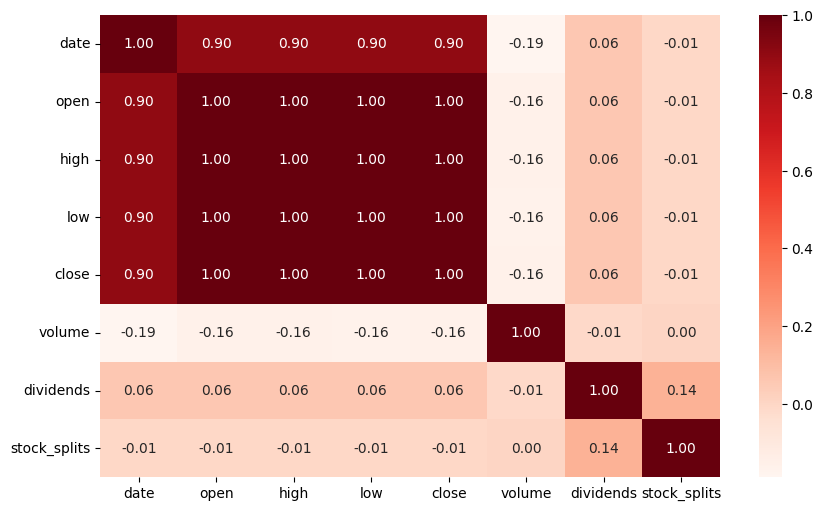

In [18]:
# Correlation Of Features
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(), annot=True, cmap="Reds", fmt=".2f")
plt.show()

``` Correlation Insights```

* Open, High, Low, and Close prices show a strong positive correlation, indicating they move together.

* There is high multicollinearity among price-related features, so using all of them may be redundant for modeling.

* Volume has a weak negative correlation with price, suggesting limited direct influence on price movement.

* Dividends and stock splits have negligible correlation with stock prices as they are corporate actions.

* Date shows a strong correlation with price, reflecting the long-term trend in the stock.

02 -  Close price over time

In [19]:
data[['date','close']].head(5)

,date,close
0,2002-08-12,29.519140
1,2002-08-13,29.119476
2,2002-08-14,27.111877
4,2002-08-16,27.046812
5,2002-08-19,26.377609


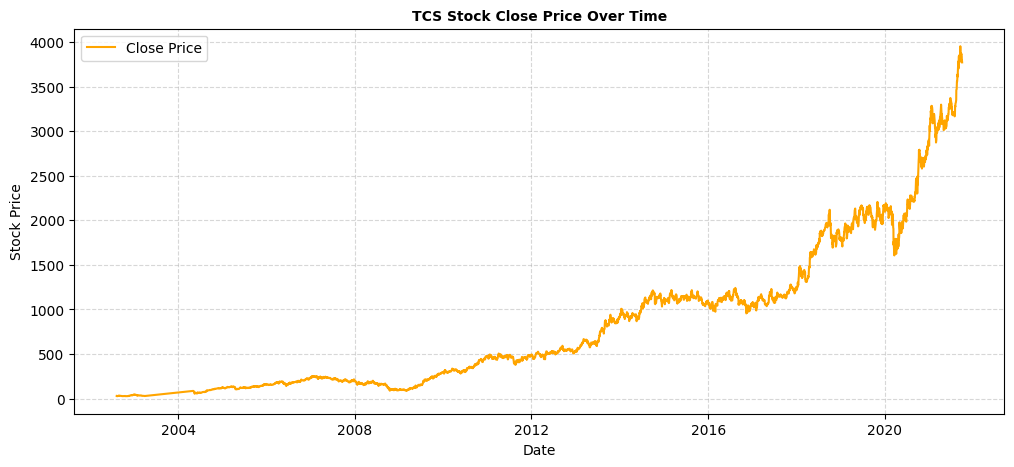

In [20]:
# plot graph
plt.figure(figsize=(12,5))
plt.plot(data['date'], data['close'], 
         color='orange',label='Close Price')

# Grid 
plt.grid(True, linestyle='--', alpha=0.5)

# label and title
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('TCS Stock Close Price Over Time',fontsize = 10 , fontweight = "bold")
plt.legend()
plt.show()

03 - Volume, Dividends, Stock Splits

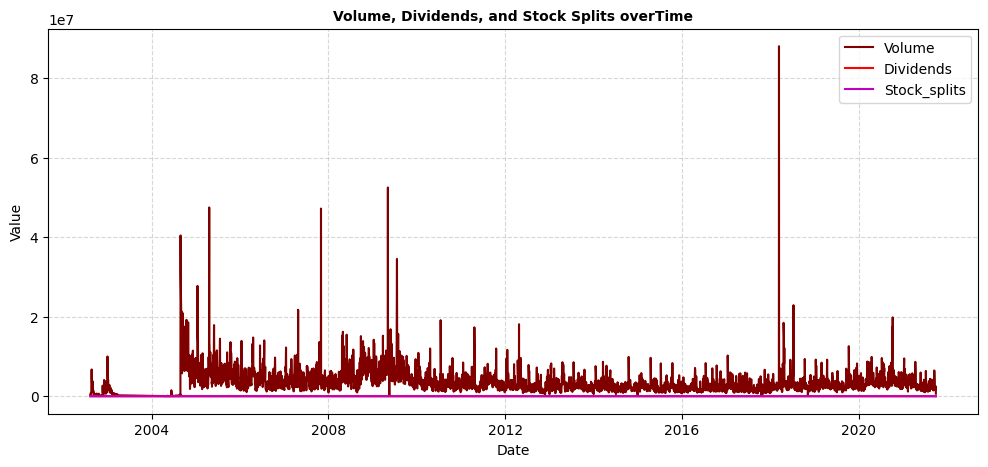

In [21]:
# plot graph
plt.figure(figsize=(12, 5))

plt.plot(data['date'], data['volume'], label='Volume', color='maroon')
plt.plot(data['date'], data['dividends'], label='Dividends',
color='r')
plt.plot(data['date'], data['stock_splits'], label='Stock_splits',
color='m')

# grid 
plt.grid(True, linestyle='--', alpha=0.5)

# label and title
plt.title('Volume, Dividends, and Stock Splits overTime', fontsize = 10 , fontweight = "bold")
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

04 - Close vs Volume

In [22]:
data[["close","volume"]].head(5)

,close,volume
0,29.519140,212976
1,29.119476,153576
2,27.111877,822776
4,27.046812,811856
5,26.377609,205880


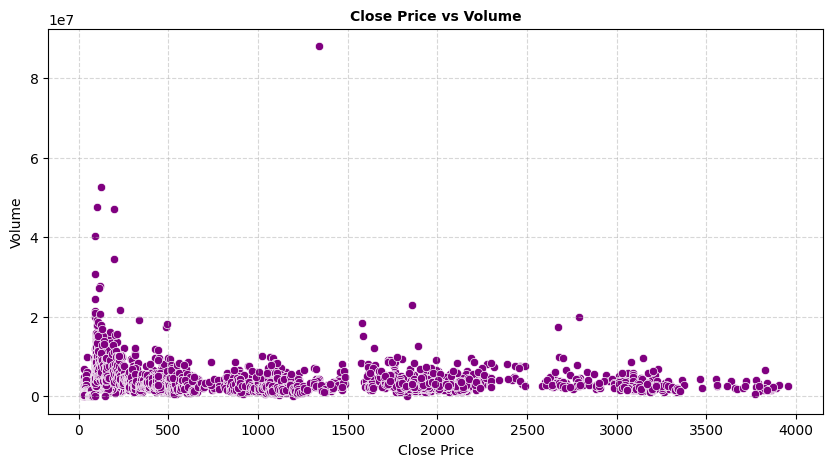

In [23]:
# plot graph
plt.figure(figsize= (10,5))
sns.scatterplot(y = data['volume'], x = data['close'],color="purple")

# grid 
plt.grid(True, linestyle='--', alpha=0.5)

#label and title
plt.ylabel('Volume')
plt.xlabel('Close Price')
plt.title('Close Price vs Volume', fontsize = 10 , fontweight= "bold")
plt.show()

05 Close Price vs Dividends

In [24]:
data[["close","dividends"]].head(5)

,close,dividends
0,29.519140,0.0
1,29.119476,0.0
2,27.111877,0.0
4,27.046812,0.0
5,26.377609,0.0


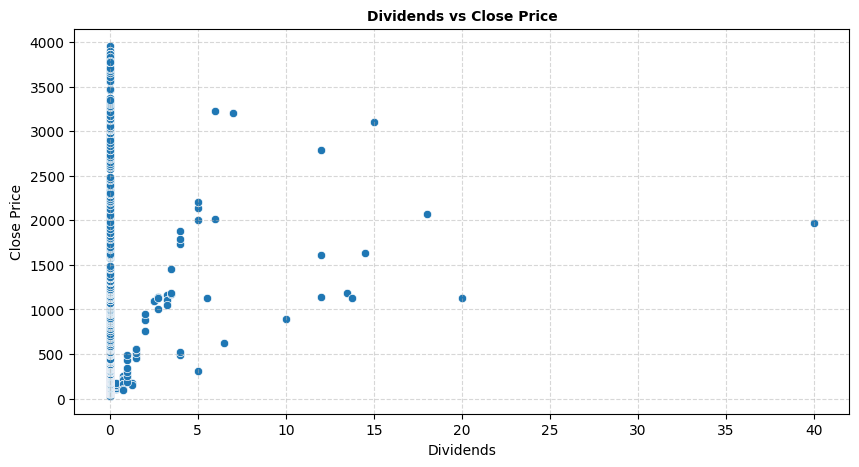

In [25]:
# plot the graph 
plt.figure(figsize= (10,5))
sns.scatterplot(x=data['dividends'], y=data['close'],)

# grid 
plt.grid(True, linestyle='--', alpha=0.5)

# label and title 
plt.xlabel('Dividends')
plt.ylabel('Close Price')
plt.title('Dividends vs Close Price',fontsize = 10 , fontweight = "bold")
plt.show()

06 close vs stock_split

In [26]:
data[["close","stock_splits"]].head(5)

,close,stock_splits
0,29.519140,0
1,29.119476,0
2,27.111877,0
4,27.046812,0
5,26.377609,0


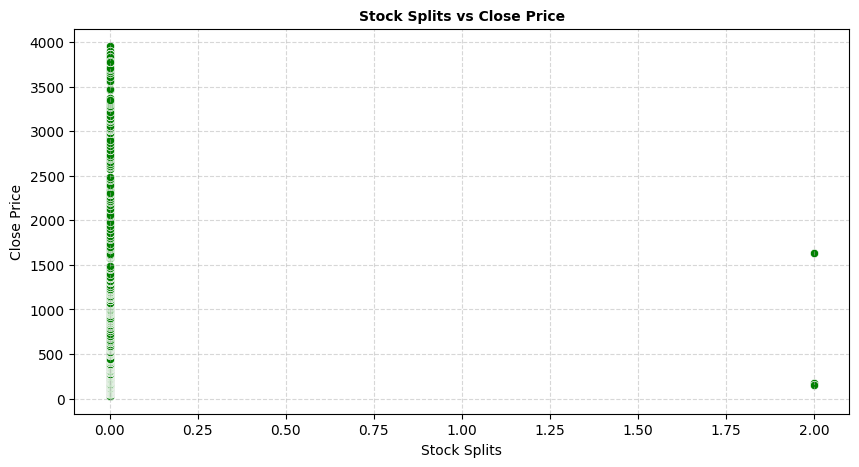

In [27]:
# Close Price vs Stock Splits 
plt.figure(figsize= (10,5))
sns.scatterplot(x=data['stock_splits'],y=data['close'],color='green')

# grid
plt.grid(True, linestyle='--', alpha=0.5)

# title and label
plt.xlabel('Stock Splits')
plt.ylabel('Close Price')
plt.title('Stock Splits vs Close Price',fontsize = 10 , fontweight = "bold")
plt.show()


07 - Moving Averages
#####  Close price and moving average


In [28]:
data['30-Day Moving Avg'] = data['close'].rolling(window=30).mean()
data.head()

,date,open,high,low,close,volume,dividends,stock_splits,30-Day Moving Avg
0,2002-08-12,28.794172,29.742206,28.794172,29.519140,212976,0.0,0,NaN
1,2002-08-13,29.556316,30.030333,28.905705,29.119476,153576,0.0,0,NaN
2,2002-08-14,29.184536,29.184536,26.563503,27.111877,822776,0.0,0,NaN
4,2002-08-16,26.972458,28.255089,26.582090,27.046812,811856,0.0,0,NaN
5,2002-08-19,27.269876,27.269876,26.126661,26.377609,205880,0.0,0,NaN


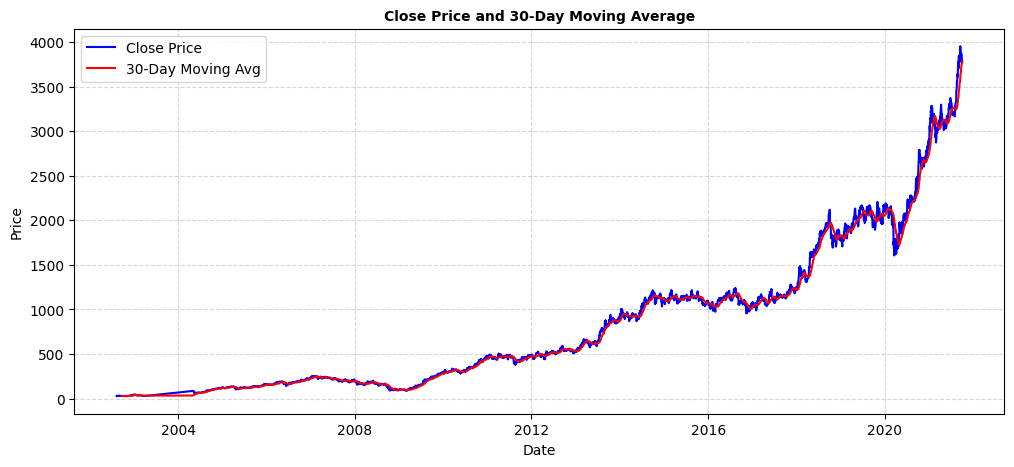

In [29]:
# plot the graph 
plt.figure(figsize = (12,5))
plt.plot(data['date'], data['close'], label='Close Price',color='b')
plt.plot(data['date'], data['30-Day Moving Avg'], label='30-Day Moving Avg', color='r')

# plot grid
plt.grid(True, linestyle='--', alpha=0.5)

# plot label and title 
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Close Price and 30-Day Moving Average',fontsize = 10 , fontweight = "bold")
plt.legend()
plt.show()

08 -  50-day and 200-day moving averages

In [30]:
data['MA50'] = data['close'].rolling(window=50).mean()
data['MA200'] = data['close'].rolling(window=200).mean()

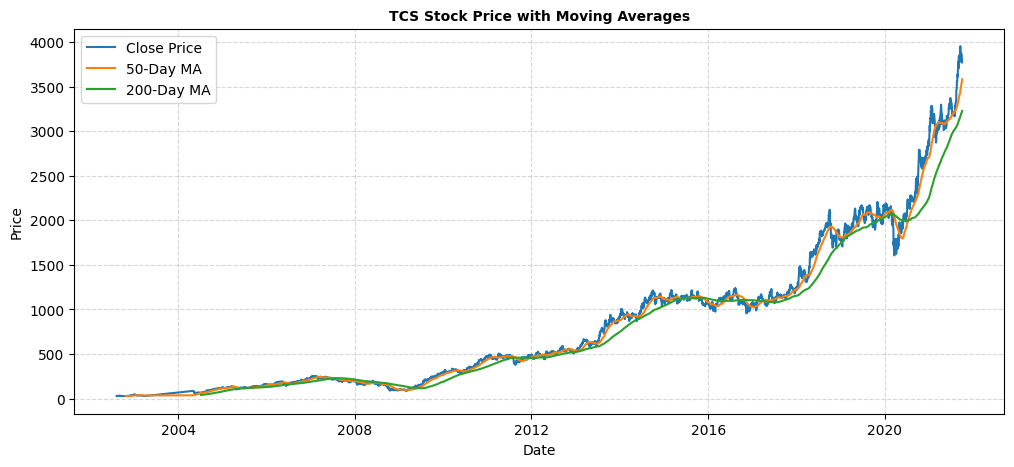

In [31]:
# Plot with Moving Averages
plt.figure(figsize=(12, 5))

# grid
plt.grid(linestyle='--', alpha=0.5)

plt.plot(data['date'], data['close'], label='Close Price')
plt.plot(data['date'], data['MA50'], label='50-Day MA')
plt.plot(data['date'], data['MA200'], label='200-Day MA')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('TCS Stock Price with Moving Averages',fontsize = 10 , fontweight = "bold")
plt.legend()
plt.show()

```Moving Average Insights (TCS Stock)```

* The stock shows a strong long-term upward trend, as the closing price consistently rises over time.

* The 50-day moving average closely follows the price, capturing short-term trend changes.

* The 200-day moving average remains smooth, indicating stable long-term growth.

* Periods where the 50-day MA stays above the 200-day MA reflect bullish market conditions.

* Short-term price corrections do not break the long-term trend, showing overall market strength.

09 - Moving Average Crossover Strategy

In [32]:
# Moving Average Crossover Strategy
data['Short_MA'] = data['close'].rolling(window=5).mean()
data['Long_MA'] = data['close'].rolling(window=30).mean()

# Creating a trading signals based on moving average crossovers
data['Signal'] = np.where(data['Short_MA'] > data['Long_MA'], 1,-1)

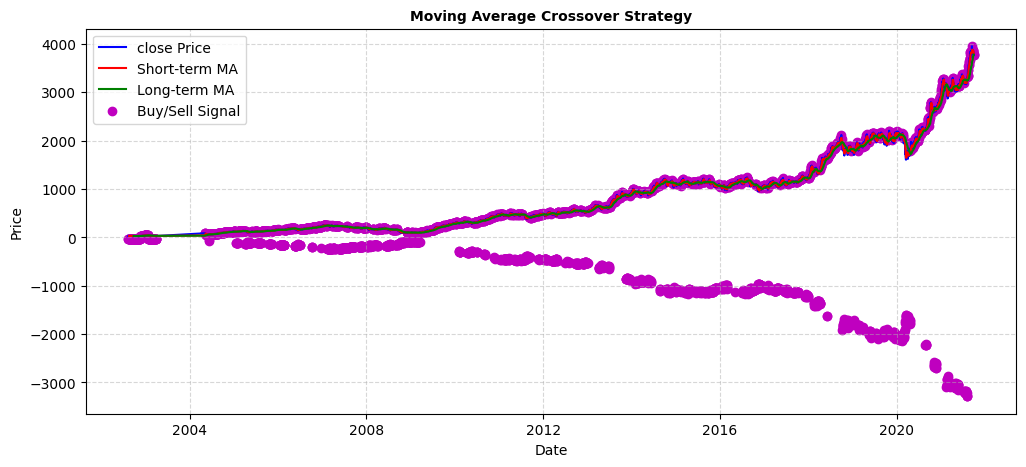

In [33]:
# Plot the strategy signals

plt.figure(figsize=(12, 5))
plt.plot(data['date'], data['close'], label='close Price',color='b')
plt.plot(data['date'], data['Short_MA'], label='Short-term MA',color='r')
plt.plot(data['date'], data['Long_MA'], label='Long-term MA',color='g')
plt.scatter(data['date'], data['close'] * data['Signal'],label='Buy/Sell Signal', marker='o', color='m')

# grid
plt.grid(linestyle = "--" , alpha = 0.5)

# label and title
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Moving Average Crossover Strategy',fontsize = 10 , fontweight = "bold")
plt.legend()
plt.show()

10 - Daily Price Change

In [34]:
data['Daily_Price_Change'] = data['close'].pct_change() * 100

In [35]:
data[['open','close','Daily_Price_Change']].head()

,open,close,Daily_Price_Change
0,28.794172,29.519140,NaN
1,29.556316,29.119476,-1.353915
2,29.184536,27.111877,-6.894351
4,26.972458,27.046812,-0.239988
5,27.269876,26.377609,-2.474239


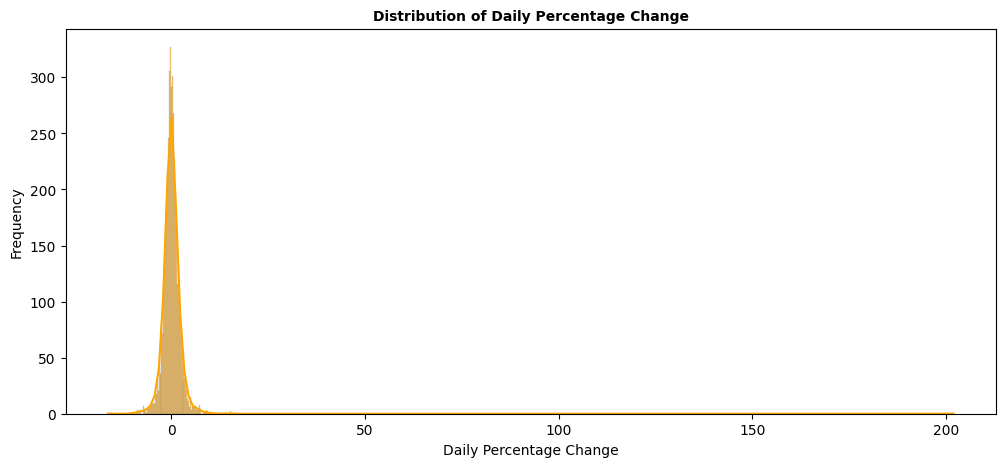

In [36]:
# plot figure
plt.figure(figsize=(12, 5))

sns.histplot(data['Daily_Price_Change'].dropna(), kde=True,color='orange')

# label and title 
plt.xlabel('Daily Percentage Change')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Percentage Change',fontsize = 10 , fontweight = "bold")
plt.show()

### Feature Engineering

* Extract features like Year, Month, Day, Day of Week from Date.
* Create lag features (e.g., previous day’s close, previous day’s high/low)

In [37]:
data['Year'] = data['date'].dt.year
data['Month'] = data['date'].dt.month
data['Day'] = data['date'].dt.day
data['Day_of_Week'] = data['date'].dt.dayofweek

In [38]:
data.head()

,date,open,high,low,close,volume,dividends,stock_splits,30-Day Moving Avg,MA50,MA200,Short_MA,Long_MA,Signal,Daily_Price_Change,Year,Month,Day,Day_of_Week
0,2002-08-12,28.794172,29.742206,28.794172,29.519140,212976,0.0,0,NaN,NaN,NaN,NaN,NaN,-1,NaN,2002,8,12,0
1,2002-08-13,29.556316,30.030333,28.905705,29.119476,153576,0.0,0,NaN,NaN,NaN,NaN,NaN,-1,-1.353915,2002,8,13,1
2,2002-08-14,29.184536,29.184536,26.563503,27.111877,822776,0.0,0,NaN,NaN,NaN,NaN,NaN,-1,-6.894351,2002,8,14,2
4,2002-08-16,26.972458,28.255089,26.582090,27.046812,811856,0.0,0,NaN,NaN,NaN,NaN,NaN,-1,-0.239988,2002,8,16,4
5,2002-08-19,27.269876,27.269876,26.126661,26.377609,205880,0.0,0,NaN,NaN,NaN,27.834983,NaN,-1,-2.474239,2002,8,19,0


In [39]:
# Lag Features
data['Prev_close'] = data['close'].shift(1)
data.dropna(inplace=True) # Drop rows with NaN values from shifting

In [40]:
data.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'dividends',
       'stock_splits', '30-Day Moving Avg', 'MA50', 'MA200', 'Short_MA',
       'Long_MA', 'Signal', 'Daily_Price_Change', 'Year', 'Month', 'Day',
       'Day_of_Week', 'Prev_close'],
      dtype='object')

In [41]:
# extract the important column from the dataset for furthure analysis
features= ['open', 'high', 'low','close','volume', 'Prev_close','Day_of_Week', 'Month']

In [42]:
# Download Clean data for furthure Analysis
data = data[features]

data.to_csv('TCS_cleaned_data.csv', index=False)

print("Dataset saved successfully")

Dataset saved successfully
